## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## Load Dataset

In [2]:
df = pd.read_csv("Employee_Salaries.csv")

df.head()

,Department,Department_Name,Division,Gender,Base_Salary,Overtime_Pay,Longevity_Pay,Grade
0,ABS,Alcohol Beverage Services,ABS 85 Administration,M,175873.000,0.00,0.0,M2
1,ABS,Alcohol Beverage Services,ABS 85 Administration,M,145613.360,0.00,0.0,M3
2,ABS,Alcohol Beverage Services,ABS 85 Administration,F,136970.000,0.00,0.0,M3
3,ABS,Alcohol Beverage Services,ABS 85 Administrative Services,F,89432.694,0.00,2490.0,21
4,ABS,Alcohol Beverage Services,ABS 85 Administrative Services,F,78947.000,456.68,6257.7,16


In [3]:
df.tail()

,Department,Department_Name,Division,Gender,Base_Salary,Overtime_Pay,Longevity_Pay,Grade
10286,TBS,Department of Technology and Enterprise Busine...,TBS 34 OSP Low Code Governance and Administration,M,134500.0000,0.0,0.00,N28
10287,ZAH,Office of Zoning and Administrative Hearings,ZAH 05 Director,F,215032.1000,0.0,0.00,NaN
10288,ZAH,Office of Zoning and Administrative Hearings,ZAH 05 Office of Zoning and Administrative Hea...,F,84365.5529,0.0,0.00,N18
10289,ZAH,Office of Zoning and Administrative Hearings,ZAH 05 Zoning and Administrative Hearings,F,98228.0000,0.0,1596.27,N21
10290,ZAH,Office of Zoning and Administrative Hearings,ZAH 05 Zoning and Administrative Hearings,F,177976.3100,0.0,0.00,N35


## Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10291 entries, 0 to 10290
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Department       10291 non-null  str    
 1   Department_Name  10291 non-null  str    
 2   Division         10291 non-null  str    
 3   Gender           10291 non-null  str    
 4   Base_Salary      10291 non-null  float64
 5   Overtime_Pay     10291 non-null  float64
 6   Longevity_Pay    10291 non-null  float64
 7   Grade            10258 non-null  str    
dtypes: float64(3), str(5)
memory usage: 643.3 KB


## Check Missing Values

In [5]:
df.isnull().sum()

Department          0
Department_Name     0
Division            0
Gender              0
Base_Salary         0
Overtime_Pay        0
Longevity_Pay       0
Grade              33
dtype: int64

In [6]:
df["Grade"] = pd.to_numeric(df["Grade"], errors="coerce")

In [7]:
df["Grade"] = df["Grade"].fillna(df["Grade"].median())

In [8]:
df.isnull().sum()

Department         0
Department_Name    0
Division           0
Gender             0
Base_Salary        0
Overtime_Pay       0
Longevity_Pay      0
Grade              0
dtype: int64

## Select Important Features

In [9]:
data = df[["Base_Salary", "Overtime_Pay", "Longevity_Pay"]]

data.head()

,Base_Salary,Overtime_Pay,Longevity_Pay
0,175873.000,0.00,0.0
1,145613.360,0.00,0.0
2,136970.000,0.00,0.0
3,89432.694,0.00,2490.0
4,78947.000,456.68,6257.7


## Basic Statistics

In [10]:
data.describe()

,Base_Salary,Overtime_Pay,Longevity_Pay
count,10291.000000,10291.000000,10291.000000
mean,90312.165744,8081.288954,1533.882816
std,31240.842929,16491.833017,3209.041070
min,11147.240000,0.000000,0.000000
25%,70023.000000,0.000000,0.000000
50%,87328.000000,258.420000,0.000000
75%,108084.000000,9190.970000,1225.680000
max,292000.000000,227428.990000,20279.460000


## Data Visualization

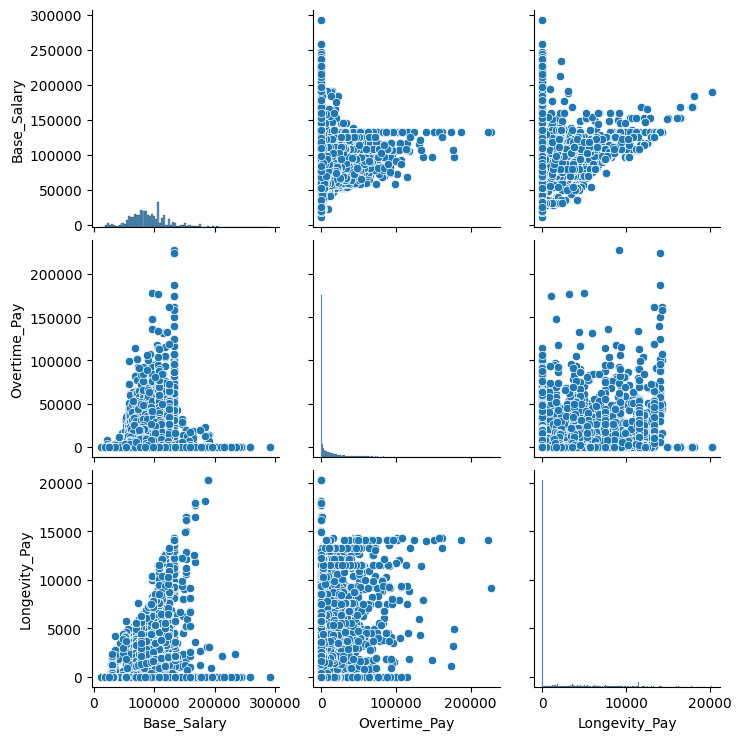

In [11]:
sns.pairplot(data)
plt.show()

## Feature Scaling

In [12]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
scaled_data[:5]

array([[ 2.7388823 , -0.49004144, -0.47801113],
       [ 1.77024293, -0.49004144, -0.47801113],
       [ 1.4935609 , -0.49004144, -0.47801113],
       [-0.02815271, -0.49004144,  0.2979593 ],
       [-0.36380958, -0.46234881,  1.47210541]])

## Create Dendrogram

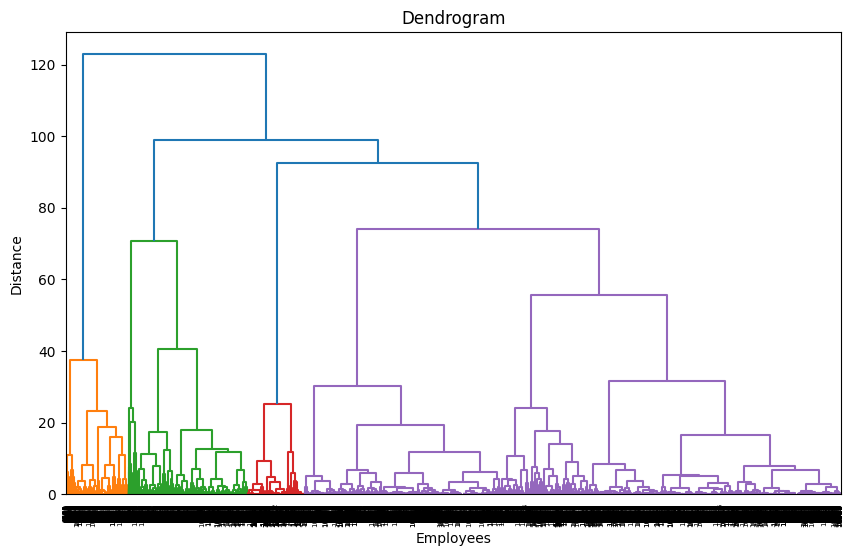

In [13]:
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Employees")
plt.ylabel("Distance")
plt.show()

## Apply Agglomerative Clustering

In [14]:
model = AgglomerativeClustering(n_clusters=3)
clusters = model.fit_predict(scaled_data)
clusters

array([0, 0, 0, ..., 0, 0, 0], shape=(10291,))

## Add Cluster Column

In [15]:
df["Cluster"] = clusters

df.head()

,Department,Department_Name,Division,Gender,Base_Salary,Overtime_Pay,Longevity_Pay,Grade,Cluster
0,ABS,Alcohol Beverage Services,ABS 85 Administration,M,175873.000,0.00,0.0,18.0,0
1,ABS,Alcohol Beverage Services,ABS 85 Administration,M,145613.360,0.00,0.0,18.0,0
2,ABS,Alcohol Beverage Services,ABS 85 Administration,F,136970.000,0.00,0.0,18.0,0
3,ABS,Alcohol Beverage Services,ABS 85 Administrative Services,F,89432.694,0.00,2490.0,21.0,0
4,ABS,Alcohol Beverage Services,ABS 85 Administrative Services,F,78947.000,456.68,6257.7,16.0,0


## Cluster Count

In [16]:
df["Cluster"].value_counts()

Cluster
0    7872
2    1584
1     835
Name: count, dtype: int64

## Cluster Visualization

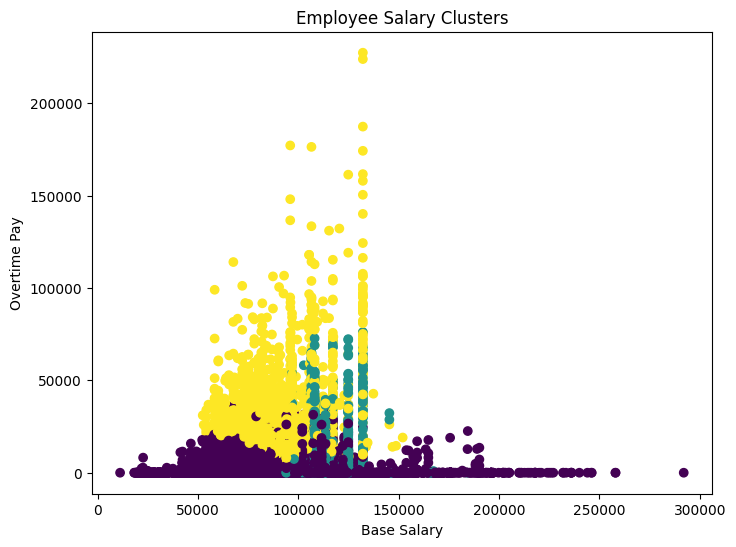

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(df["Base_Salary"], df["Overtime_Pay"],c=df["Cluster"])
plt.xlabel("Base Salary")
plt.ylabel("Overtime Pay")
plt.title("Employee Salary Clusters")
plt.show()

## Average Salary Per Cluster

In [18]:
cluster_analysis = df.groupby("Cluster")[["Base_Salary","Overtime_Pay","Longevity_Pay"]].mean()
cluster_analysis

,Base_Salary,Overtime_Pay,Longevity_Pay
Cluster,,,
0,87587.086920,2256.248070,747.950146
1,114656.268878,13847.028802,10369.600874
2,91022.073819,33990.587607,782.012487


## Heatmap for Better Visualization

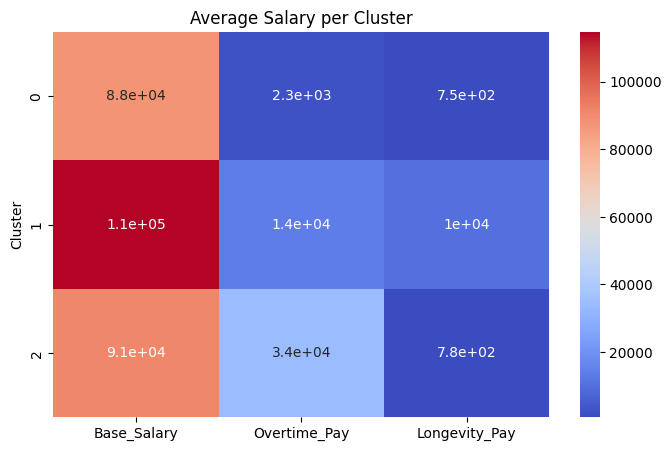

In [19]:
plt.figure(figsize=(8,5))
sns.heatmap(cluster_analysis, annot=True, cmap="coolwarm")
plt.title("Average Salary per Cluster")
plt.show()